In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
"""
This notebook does multi-label classification using xgboost. 
"""

Data excludes Land_Vehicle class

In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import (
    accuracy_score, classification_report,
    multilabel_confusion_matrix, f1_score
)


train_p = Path(r".\Data_v3\Bootstrapped_Audios_No_Land_Vehicles\FeatureTable\train_df.csv")
test_p = Path(r".\Data_v3\Bootstrapped_Audios_No_Land_Vehicles\FeatureTable\test_df.csv")
train_df = pd.read_csv(train_p)
test_df = pd.read_csv(test_p)


label_cols = ["label_overlay_Airplanes", "label_overlay_Drones", "label_overlay_Explosion",
              "label_overlay_Gunshots", "label_overlay_Helicopter", "label_overlay_shortened_unlabeled"]
non_feature_cols = ["filepath", "label_base"] + label_cols
feature_cols = [c for c in train_df.columns if c not in non_feature_cols]

X_train = train_df[feature_cols]
y_train = train_df[label_cols]
X_test = test_df[feature_cols]
y_test = test_df[label_cols]

target_names = [c.replace("label_overlay_", "") for c in label_cols]

Cross Validation

In [4]:
clf = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",       # independent per-label probability
    eval_metric="logloss",
    tree_method="hist",
    multi_strategy="multi_output_tree", # native multi-label support, shares trees across labels
    n_jobs=-1,
)

cv = MultilabelStratifiedKFold(n_splits=10, shuffle=True)

scoring = ["accuracy", "f1_macro", "precision_macro", "recall_macro"]

cv_results = cross_validate(
    clf, X_train, y_train,
    cv=cv, scoring=scoring, return_train_score=True, n_jobs=-1
)

print("=== Cross-Validation Results (10-fold) ===")
for metric in scoring:
    scores = cv_results[f"test_{metric}"]
    print(f"{metric:15s}: mean={scores.mean():.4f}  std={scores.std():.4f}  folds={np.round(scores, 3)}")


=== Cross-Validation Results (10-fold) ===
accuracy       : mean=0.5278  std=0.0511  folds=[0.418 0.527 0.496 0.589 0.511 0.605 0.504 0.569 0.548 0.509]
f1_macro       : mean=0.8691  std=0.0192  folds=[0.843 0.892 0.852 0.871 0.84  0.893 0.855 0.887 0.878 0.88 ]
precision_macro: mean=0.8432  std=0.0253  folds=[0.814 0.875 0.868 0.864 0.786 0.852 0.84  0.844 0.838 0.85 ]
recall_macro   : mean=0.8990  std=0.0305  folds=[0.876 0.912 0.838 0.879 0.903 0.939 0.871 0.936 0.922 0.915]


Test on Unseen


=== Final Held-Out Test ===
Test Subset Accuracy: 0.4622
                     precision    recall  f1-score   support

          Airplanes       0.87      0.88      0.87       240
             Drones       0.83      0.82      0.83       225
          Explosion       0.80      0.92      0.86       242
           Gunshots       0.76      0.86      0.81       225
         Helicopter       0.91      0.89      0.90       239
shortened_unlabeled       0.81      0.93      0.86       230

          micro avg       0.83      0.88      0.85      1401
          macro avg       0.83      0.88      0.85      1401
       weighted avg       0.83      0.88      0.86      1401
        samples avg       0.80      0.86      0.81      1401



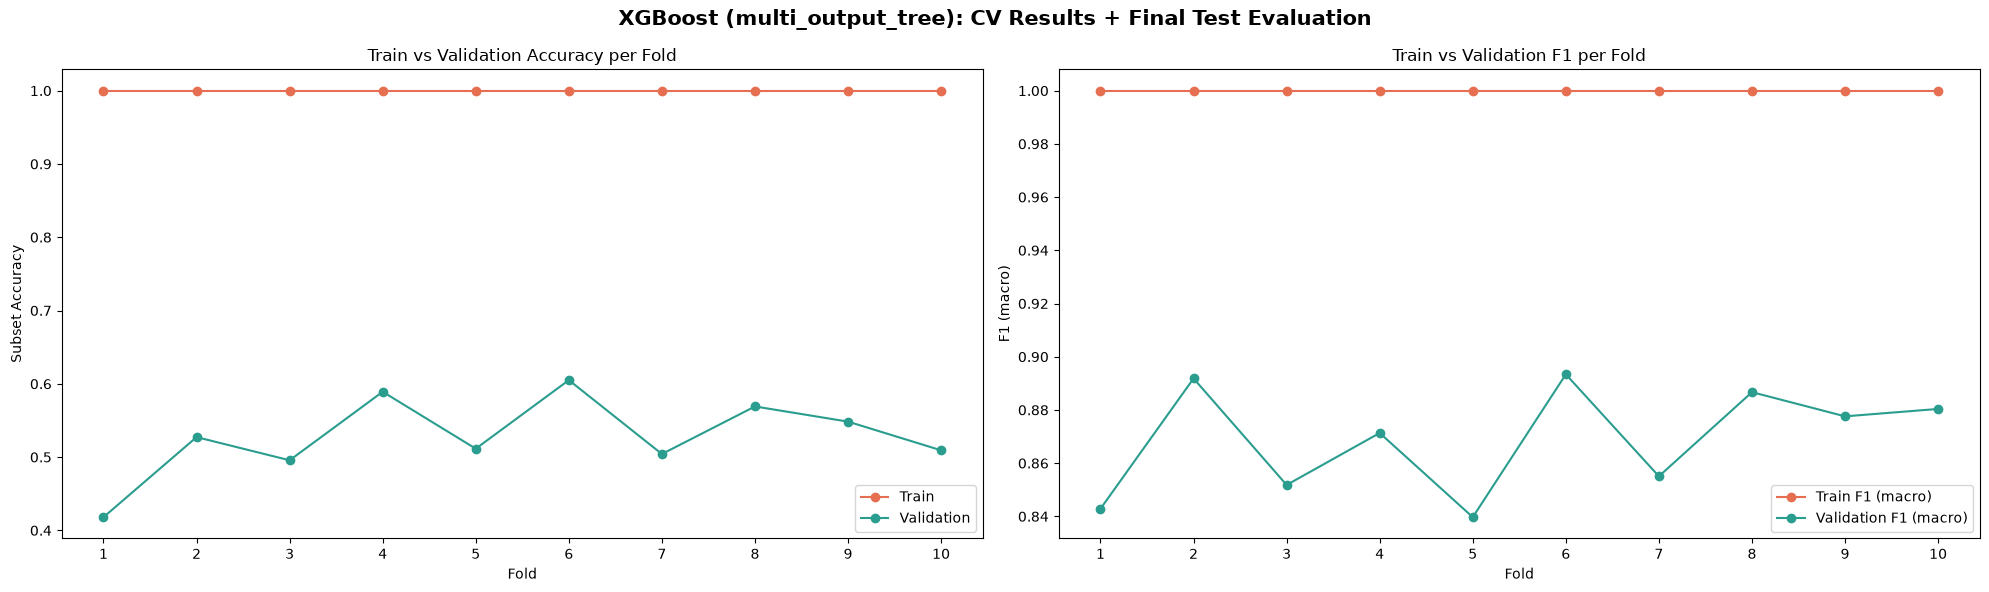

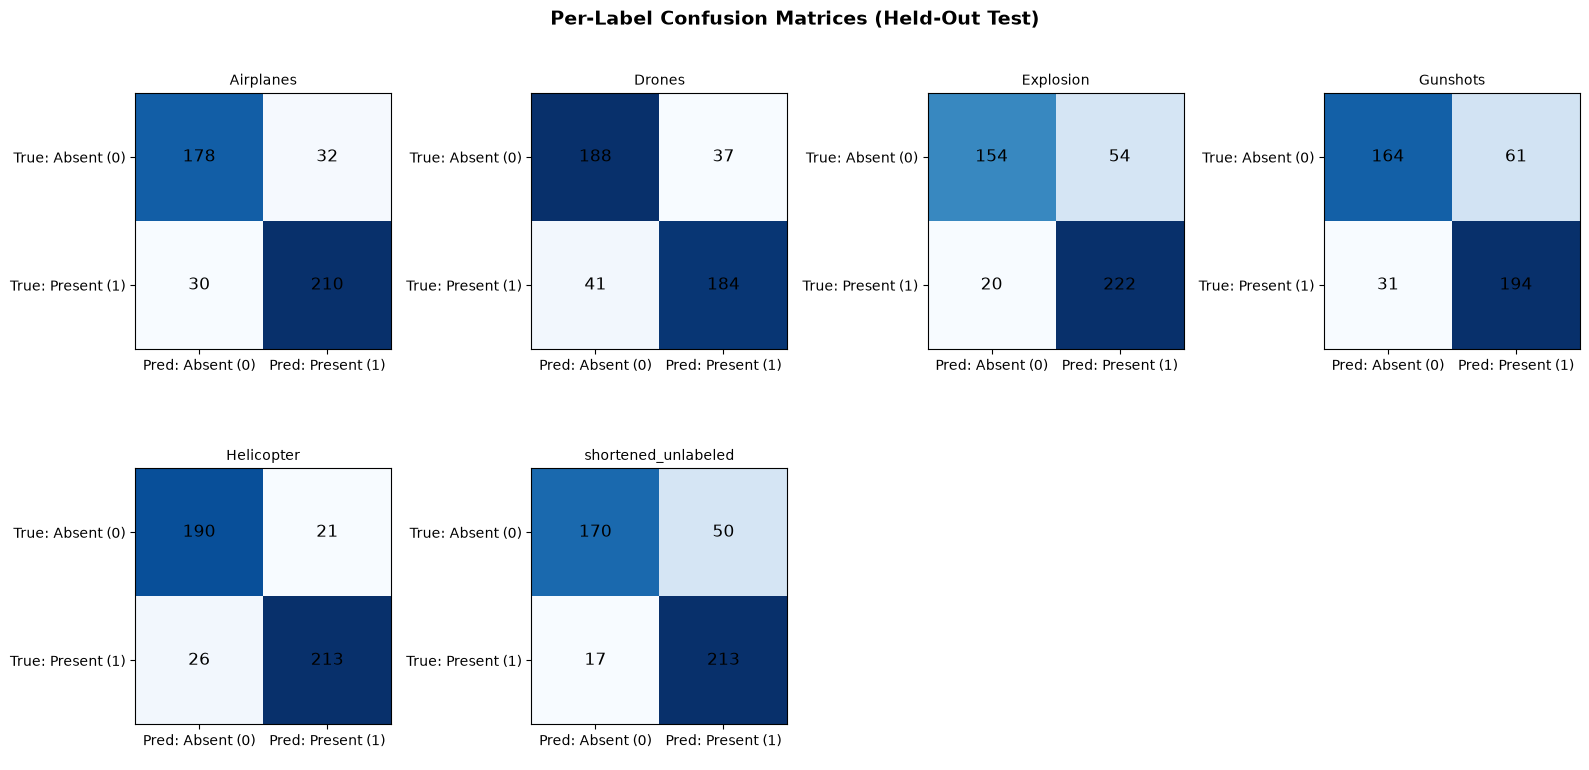

In [ ]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)  # subset (exact-match) accuracy

print("\n=== Final Held-Out Test ===")
print(f"Test Subset Accuracy: {test_acc:.4f}")
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))

# --- Plot 1: Train vs validation accuracy per fold ---
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle("XGBoost (multi_output_tree): CV Results + Final Test Evaluation", fontsize=15, fontweight="bold")

ax = axes[0]
folds = np.arange(1, len(cv_results["test_accuracy"]) + 1)
ax.plot(folds, cv_results["train_accuracy"], marker="o", label="Train", color="#e76f51")
ax.plot(folds, cv_results["test_accuracy"], marker="o", label="Validation", color="#2a9d8f")
ax.set_xticks(folds)
ax.set_xlabel("Fold")
ax.set_ylabel("Subset Accuracy")
ax.set_title("Train vs Validation Accuracy per Fold")
ax.legend()

ax = axes[1]
ax.plot(folds, cv_results["train_f1_macro"], marker="o", label="Train F1 (macro)", color="#e76f51")
ax.plot(folds, cv_results["test_f1_macro"], marker="o", label="Validation F1 (macro)", color="#2a9d8f")
ax.set_xticks(folds)
ax.set_xlabel("Fold")
ax.set_ylabel("F1 (macro)")
ax.set_title("Train vs Validation F1 per Fold")
ax.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: Multi-label confusion matrices (one per label, grid) ---
mcm = multilabel_confusion_matrix(y_test, y_pred)  # shape (n_labels, 2, 2)

n_labels = len(target_names)
ncols = 4
nrows = int(np.ceil(n_labels / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.flatten()

for i, name in enumerate(target_names):
    ax = axes[i]
    cm = mcm[i]
    ax.imshow(cm, cmap="Blues")
    for r in range(2):
        for c in range(2):
            ax.text(c, r, cm[r, c], ha="center", va="center",
                     color="black", fontsize=12)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred: Absent (0)", "Pred: Present (1)"])
    ax.set_yticklabels(["True: Absent (0)", "True: Present (1)"])
    ax.set_title(name, fontsize=10)

for j in range(n_labels, len(axes)):
    axes[j].axis("off")

fig.suptitle("Per-Label Confusion Matrices (Held-Out Test)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

from pathlib import Path

# SAVE MODEL
model_dir = Path("./Model/xgboost")
model_dir.mkdir(parents=True, exist_ok=True)

clf.save_model(model_dir / "multilabel_xgb_model.json")
with open(model_dir / "feature_cols.json", "w") as f:
    json.dump(feature_cols, f)
with open(model_dir / "target_names.json", "w") as f:
    json.dump(target_names, f)

Feature Importance

In [ ]:
def top_features_by_cumulative_importance(clf, feature_names, threshold=0.90):
    importances = clf.feature_importances_
    order = np.argsort(importances)[::-1]
    sorted_importances = importances[order]
    sorted_names = np.array(feature_names)[order]
    cumulative = np.cumsum(sorted_importances)
    n_features = np.searchsorted(cumulative, threshold) + 1
    return pd.DataFrame({
        "feature": sorted_names[:n_features],
        "importance": sorted_importances[:n_features],
        "cumulative": cumulative[:n_features]
    })

top_feats = top_features_by_cumulative_importance(clf, X_train.columns, threshold=0.90)
print("\n=== Top features (90% cumulative importance) ===")
print(top_feats)


=== Top features (90% cumulative importance) ===
               feature  importance  cumulative
0         delta2_0_std    0.063797    0.063797
1    temporal_centroid    0.045291    0.109088
2         delta2_1_min    0.027452    0.136540
3           mfcc_1_min    0.018014    0.154554
4           mfcc_1_std    0.016282    0.170836
..                 ...         ...         ...
153       delta2_6_max    0.002591    0.891255
154        delta_1_min    0.002578    0.893833
155      delta2_2_mean    0.002555    0.896389
156         mfcc_8_min    0.002545    0.898934
157        mfcc_11_std    0.002511    0.901445

[158 rows x 3 columns]
